In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, chi2_contingency, ttest_1samp

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition 2.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (1470, 35)

Columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField            

In [ ]:

df["Attrition_num"] = df["Attrition"].map({"No": 0, "Yes": 1})

df[["Attrition", "Attrition_num"]].head()

,Attrition,Attrition_num
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [ ]:


def descriptive_stats(data, field):
    print("Descriptive Statistics for:", field)
    print("--------------------------------")
    print("Count:", data[field].count())
    print("Mean:", data[field].mean())
    print("Median:", data[field].median())
    print("Standard Deviation:", data[field].std())
    print("Variance:", data[field].var())
    print("Minimum:", data[field].min())
    print("Maximum:", data[field].max())
    print("Skewness:", data[field].skew())

In [ ]:
descriptive_stats(df, "MonthlyIncome")

Descriptive Statistics for: MonthlyIncome
--------------------------------
Count: 1470
Mean: 6502.931292517007
Median: 4919.0
Standard Deviation: 4707.956783097995
Variance: 22164857.07151842
Minimum: 1009
Maximum: 19999
Skewness: 1.3698166808390662


In [ ]:

random_sample = df.sample(n=150, random_state=42)

print("Random Sample Shape:", random_sample.shape)

descriptive_stats(random_sample, "MonthlyIncome")

Random Sample Shape: (150, 36)
Descriptive Statistics for: MonthlyIncome
--------------------------------
Count: 150
Mean: 6863.326666666667
Median: 5556.0
Standard Deviation: 4477.117961542449
Variance: 20044585.24156601
Minimum: 1232
Maximum: 19586
Skewness: 1.3056023864836717


In [ ]:
k = len(df) // 150

systematic_sample = df.iloc[::k]

systematic_sample = systematic_sample.head(150)

print("Systematic Sampling Interval k:", k)
print("Systematic Sample Shape:", systematic_sample.shape)

descriptive_stats(systematic_sample, "MonthlyIncome")

Systematic Sampling Interval k: 9
Systematic Sample Shape: (150, 36)
Descriptive Statistics for: MonthlyIncome
--------------------------------
Count: 150
Mean: 6469.093333333333
Median: 4784.0
Standard Deviation: 4867.466655482822
Variance: 23692231.642237123
Minimum: 1009
Maximum: 19847
Skewness: 1.414759490601378


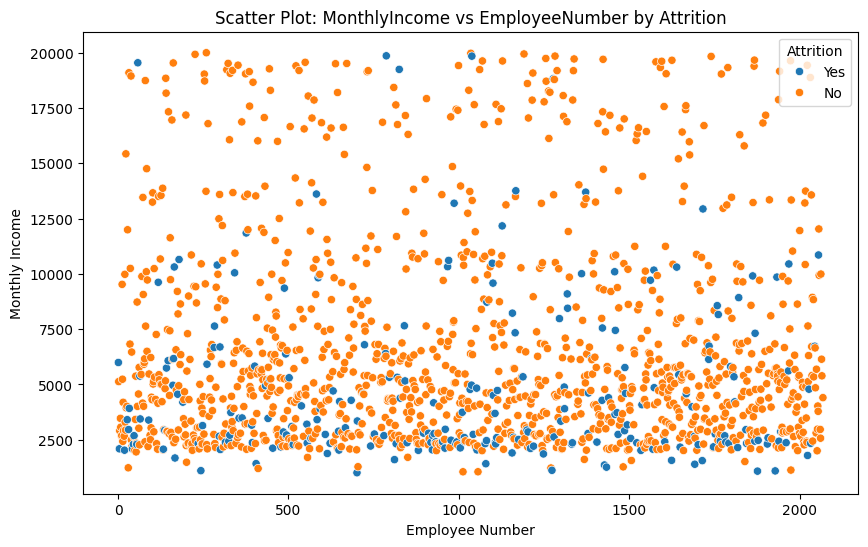

In [ ]:


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="EmployeeNumber",
    y="MonthlyIncome",
    hue="Attrition"
)
plt.title("Scatter Plot: MonthlyIncome vs EmployeeNumber by Attrition")
plt.xlabel("Employee Number")
plt.ylabel("Monthly Income")
plt.show()

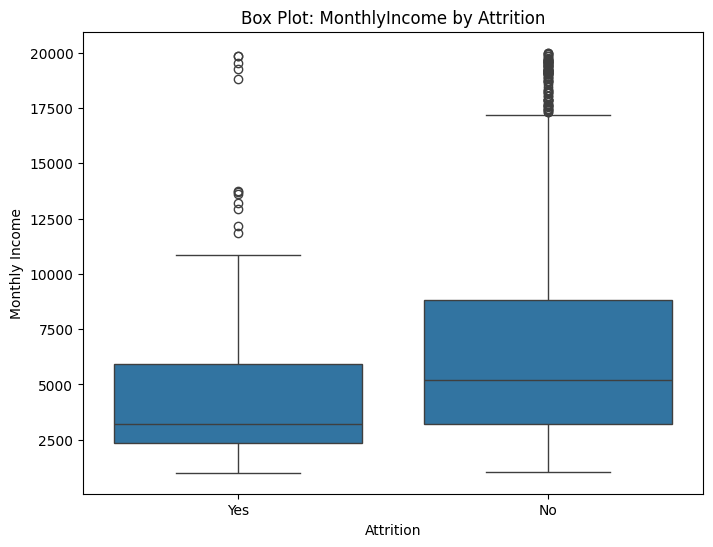

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)
plt.title("Box Plot: MonthlyIncome by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

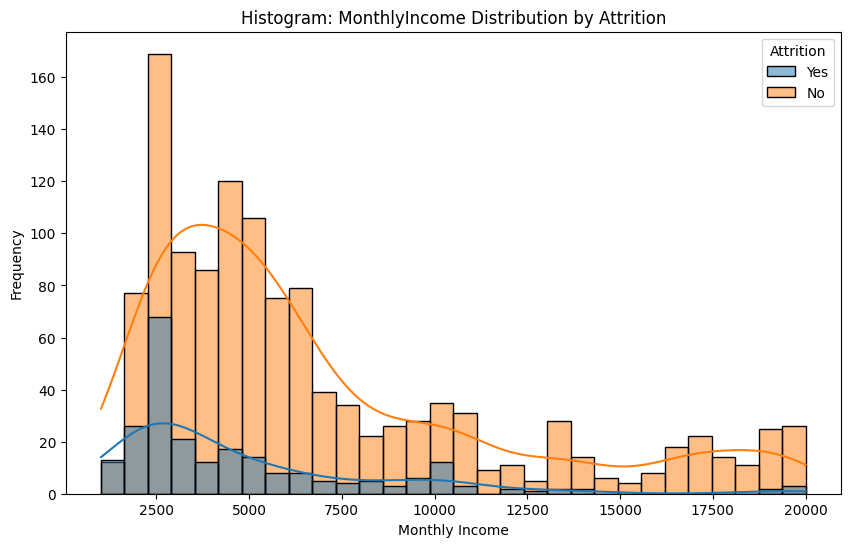

In [ ]:

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="MonthlyIncome",
    hue="Attrition",
    bins=30,
    kde=True
)
plt.title("Histogram: MonthlyIncome Distribution by Attrition")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

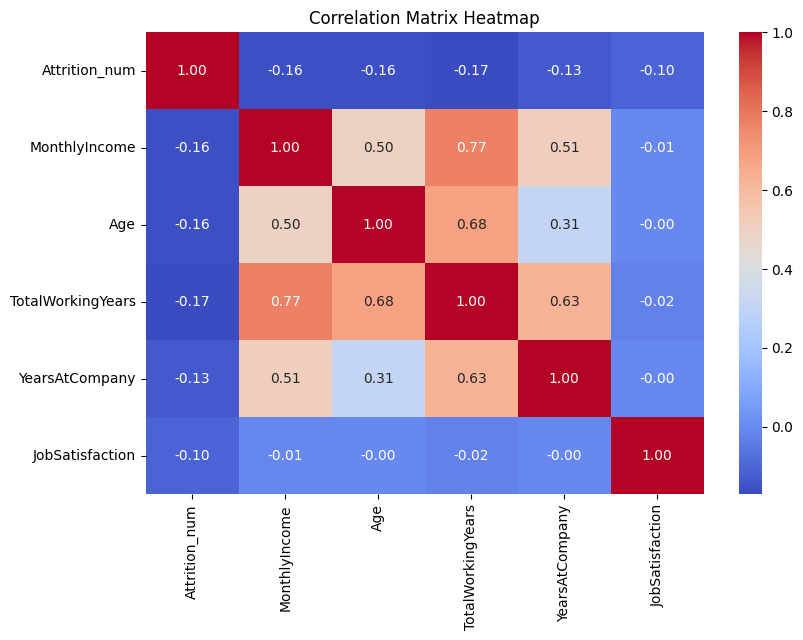

In [ ]:

selected_columns = [
    "Attrition_num",
    "MonthlyIncome",
    "Age",
    "TotalWorkingYears",
    "YearsAtCompany",
    "JobSatisfaction"
]

corr_matrix = df[selected_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:


pearson_corr, pearson_p = pearsonr(df["MonthlyIncome"], df["Attrition_num"])

print("Pearson Correlation:", pearson_corr)
print("Pearson P-value:", pearson_p)

Pearson Correlation: -0.15983958238498874
Pearson P-value: 7.147363985353761e-10


In [ ]:

spearman_corr, spearman_p = spearmanr(df["MonthlyIncome"], df["Attrition_num"])

print("Spearman Correlation:", spearman_corr)
print("Spearman P-value:", spearman_p)

Spearman Correlation: -0.19830500478881558
Spearman P-value: 1.6804049487884777e-14


In [ ]:

contingency_table = pd.crosstab(df["OverTime"], df["Attrition"])

print("Contingency Table:")
print(contingency_table)

chi2, chi_p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square Statistic:", chi2)
print("P-value:", chi_p)
print("Degrees of Freedom:", dof)

Contingency Table:
Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127

Chi-square Statistic: 87.56429365828768
P-value: 8.15842372153832e-21
Degrees of Freedom: 1


In [ ]:

population_mean = df["MonthlyIncome"].mean()

t_stat, t_p = ttest_1samp(random_sample["MonthlyIncome"], population_mean)

print("Population Mean MonthlyIncome:", population_mean)
print("Sample Mean MonthlyIncome:", random_sample["MonthlyIncome"].mean())
print("T-statistic:", t_stat)
print("P-value:", t_p)

Population Mean MonthlyIncome: 6502.931292517007
Sample Mean MonthlyIncome: 6863.326666666667
T-statistic: 0.9858850938360828
P-value: 0.3257877227077979


In [ ]:

print("D1 Analysis Completed Successfully")
print("----------------------------------")

print("Pearson Correlation:", pearson_corr)
print("Pearson P-value:", pearson_p)

print("Spearman Correlation:", spearman_corr)
print("Spearman P-value:", spearman_p)

print("One Sample T-test P-value:", t_p)

D1 Analysis Completed Successfully
----------------------------------
Pearson Correlation: -0.15983958238498874
Pearson P-value: 7.147363985353761e-10
Spearman Correlation: -0.19830500478881558
Spearman P-value: 1.6804049487884777e-14
One Sample T-test P-value: 0.3257877227077979


In [ ]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:

df["Attrition_num"] = df["Attrition"].map({"No": 0, "Yes": 1})
df["OverTime_num"] = df["OverTime"].map({"No": 0, "Yes": 1})


df_encoded = pd.get_dummies(df.drop("Attrition", axis=1), drop_first=True)

df_encoded.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,1,2,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,1,4,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,1,5,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,7,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split


X_class = df_encoded.drop("Attrition_num", axis=1)
y_class = df_encoded["Attrition_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1176, 48)
X_test shape: (294, 48)
y_train shape: (1176,)
y_test shape: (294,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-1.38855944 -1.10813858  1.44039645 -0.86335572  0.          0.86066608
   0.2797056  -0.47283217 -1.01234042 -0.9322736  -1.58233648 -0.86827746
  -0.60189535 -1.05916816 -0.33924934 -0.42929015 -0.63982217  0.
   2.54747106 -1.1673683   0.15731946  0.3574354  -0.97426331 -0.88820751
  -0.67610953 -1.14244794 -0.63641018 -0.49041445  0.63904869  0.73297674
  -0.66554097 -0.84663352 -0.34332306 -0.67620195 -0.24966102  3.2624476
   0.81447304 -0.19245009  2.18282063 -0.26835533 -0.31637564 -0.24773341
  -0.50901929 -0.52486957 -0.26099788 -0.93733358 -0.66288195 -0.63641018]
 [-2.04073779 -1.2634814  -0.52269928 -0.86335572  0.         -0.02681063
  -0.63910385  0.30937375  0.38991203 -0.9322736   1.15283407 -1.13280679
  -0.11531844 -0.65943075 -0.06636478 -0.42929015  1.21117628  0.
  -0.94552463 -1.42339685 -0.61354589  0.3574354  -1.13857331 -1.1650514
  -0.67610953 -1.14244794 -0.63641018 -0.49041445 -1.56482598  0.73297674
  -0.66554097  1.1811486  -0.34332306 -0.67620195 -0.24

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition 2.csv")

# Select features and target
X = df[["Age", "YearsAtCompany", "JobSatisfaction"]]
y = df["MonthlyIncome"]

# Handle missing values
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt


X_reg = df[["Age", "TotalWorkingYears", "YearsAtCompany", "JobLevel", "JobSatisfaction"]]
y_reg = df["MonthlyIncome"]


Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)


reg_scaler = StandardScaler()
Xr_train_scaled = reg_scaler.fit_transform(Xr_train)
Xr_test_scaled = reg_scaler.transform(Xr_test)

In [ ]:
cols = ["Age", "YearsAtCompany", "JobSatisfaction"]

outliers = []

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers.extend(df[(df[col] < lower) | (df[col] > upper)].index)

outliers = list(set(outliers))


df = df.drop(index=outliers)

print("New dataset shape:", df.shape)

New dataset shape: (1366, 35)


In [ ]:
from sklearn.model_selection import train_test_split

X = df[["Age", "YearsAtCompany", "JobSatisfaction"]]


y = df["MonthlyIncome"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1092, 3)
Testing data: (274, 3)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# Define features and target based on previous analysis (from cell nN8luZvyINxP)
X = df[["Age", "YearsAtCompany", "JobSatisfaction"]]
y = df["MonthlyIncome"]

# Split the dataset into training and testing sets (from cell nN8luZvyINxP)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)


poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_pred = poly_model.predict(X_test_poly)

ridge_model = Ridge()
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)


lasso_model = Lasso()
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)


elastic_model = ElasticNet()
elastic_model.fit(X_train, y_train)
elastic_pred = elastic_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

results = {
    'Model': ['Linear', 'Polynomial', 'Ridge', 'Lasso', 'ElasticNet'],
    'R2 Score': [
        r2_score(y_test, linear_pred),
        r2_score(y_test, poly_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred)
    ],
    'MSE': [
        mean_squared_error(y_test, linear_pred),
        mean_squared_error(y_test, poly_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred),
        mean_squared_error(y_test, elastic_pred)
    ]
}

results_df = pd.DataFrame(results)
display(results_df)

,Model,R2 Score,MSE
0,Linear,0.315596,1.267679e+07
1,Polynomial,0.314593,1.269537e+07
2,Ridge,0.315597,1.267678e+07
3,Lasso,0.315623,1.267630e+07
4,ElasticNet,0.315427,1.267993e+07


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate all models
results = []

results.append(["Linear Regression",
                mean_squared_error(y_test, linear_pred),
                r2_score(y_test, linear_pred)])

results.append(["Polynomial Regression",
                mean_squared_error(y_test, poly_pred),
                r2_score(y_test, poly_pred)])

results.append(["Ridge Regression",
                mean_squared_error(y_test, ridge_pred),
                r2_score(y_test, ridge_pred)])

results.append(["Lasso Regression",
                mean_squared_error(y_test, lasso_pred),
                r2_score(y_test, lasso_pred)])

results.append(["Elastic Net",
                mean_squared_error(y_test, elastic_pred),
                r2_score(y_test, elastic_pred)])


for model in results:
    print(model[0], "MSE:", model[1], "R²:", model[2])

Linear Regression MSE: 12676788.928073399 R²: 0.31559643435299967
Polynomial Regression MSE: 12695372.624186669 R²: 0.3145931244489706
Ridge Regression MSE: 12676783.657571563 R²: 0.31559671890063
Lasso Regression MSE: 12676296.618255487 R²: 0.3156230135282698
Elastic Net MSE: 12679929.514300013 R²: 0.31542687813305226


In [ ]:
import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "MSE", "R²"])

print("Model Comparison Table:")
print(results_df)

Model Comparison Table:
                   Model           MSE        R²
0      Linear Regression  1.267679e+07  0.315596
1  Polynomial Regression  1.269537e+07  0.314593
2       Ridge Regression  1.267678e+07  0.315597
3       Lasso Regression  1.267630e+07  0.315623
4            Elastic Net  1.267993e+07  0.315427


In [ ]:
best_model = results_df.loc[results_df["R²"].idxmax()]

print("\nBest Model:")
print(best_model)


Best Model:
Model    Lasso Regression
MSE       12676296.618255
R²               0.315623
Name: 3, dtype: object


In [ ]:

print("Intercept:", elastic_model.intercept_)

print("\nCoefficients:")
for name, coef in zip(X.columns, elastic_model.coef_):
    print(name, ":", coef)

Intercept: -2065.1166850919726

Coefficients:
Age : 180.89037599128812
YearsAtCompany : 207.3343028794663
JobSatisfaction : 38.71506814409594


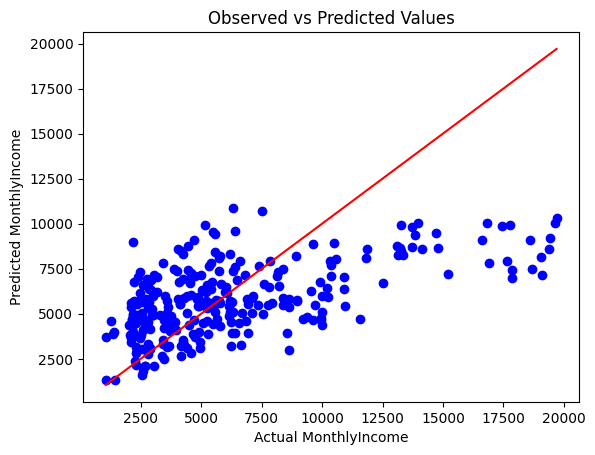

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, elastic_pred, color="blue")


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual MonthlyIncome")
plt.ylabel("Predicted MonthlyIncome")
plt.title("Observed vs Predicted Values")
plt.show()

In [ ]:
# Convert Attrition into numerical values
df["Attrition_num"] = df["Attrition"].map({"No": 0, "Yes": 1})

# Display target values
print(df[["Attrition", "Attrition_num"]].head())


  Attrition  Attrition_num
0       Yes              1
1        No              0
2       Yes              1
3        No              0
4        No              0


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd

In [ ]:
# Convert OverTime into numerical values
df["OverTime_num"] = df["OverTime"].map({"No": 0, "Yes": 1})

# Independent variables
X_class = df[[
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "JobSatisfaction",
    "OverTime_num"
]]

# Target variable
y_class = df["Attrition_num"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Create classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train and evaluate models
classification_results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    classification_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# Create results table
classification_results_df = pd.DataFrame(
    classification_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

print("Classification Model Results:")
print(classification_results_df)

Classification Model Results:
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.813869   0.391304  0.195652  0.260870
1                  KNN  0.821168   0.451613  0.304348  0.363636
2                  SVM  0.824818   0.444444  0.173913  0.250000
3        Decision Tree  0.744526   0.260000  0.282609  0.270833
4        Random Forest  0.784672   0.303030  0.217391  0.253165


In [ ]:
# Select the best classifier based on highest F1-score
best_classifier = classification_results_df.loc[
    classification_results_df["F1-score"].idxmax()
]

print("Best Classification Model:")
print(best_classifier)

Best Classification Model:
Model             KNN
Accuracy     0.821168
Precision    0.451613
Recall       0.304348
F1-score     0.363636
Name: 1, dtype: object


In [ ]:
# Get best model name
best_model_name = best_classifier["Model"]

# Select the best model from the models dictionary
best_model = models[best_model_name]

# Train the best model again
best_model.fit(X_train_scaled, y_train)

# Predict using the best model
best_predictions = best_model.predict(X_test_scaled)

# Count predicted categories
predicted_counts = pd.Series(best_predictions).value_counts()

print("Number of elements predicted by best classifier:")
print(predicted_counts)

Number of elements predicted by best classifier:
0    243
1     31
Name: count, dtype: int64


In [ ]:
predicted_labels = pd.Series(best_predictions).map({
    0: "Employee Stayed",
    1: "Employee Left"
})

print(predicted_labels.value_counts())

Employee Stayed    243
Employee Left       31
Name: count, dtype: int64


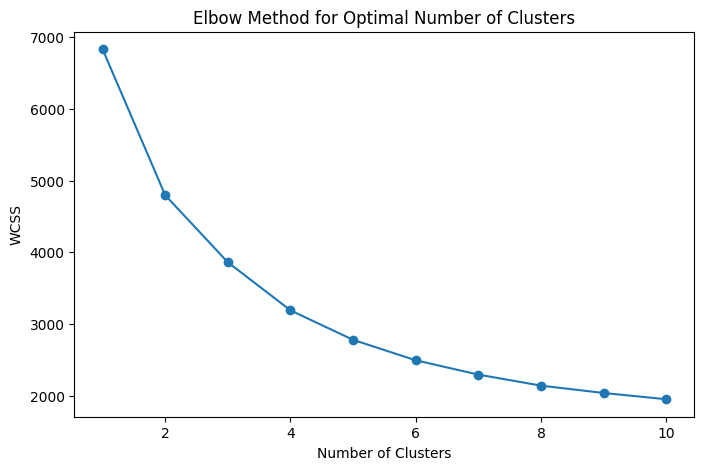

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering
X_cluster = df[[
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "JobSatisfaction"
]]

# Feature scaling
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

# Display first rows with cluster labels
df[[
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "JobSatisfaction",
    "Cluster"
]].head()

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,JobSatisfaction,Cluster
0,41,5993,8,6,4,0
1,49,5130,10,10,2,0
2,37,2090,7,0,3,1
3,33,2909,8,8,3,0
4,27,3468,6,2,2,1


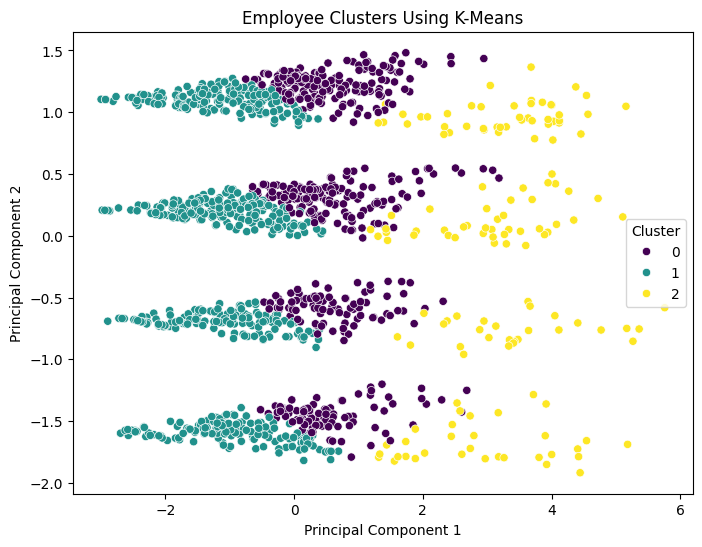

In [ ]:
# Reduce features to 2 dimensions using PCA
pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(X_cluster_scaled)

df["PCA1"] = cluster_pca[:, 0]
df["PCA2"] = cluster_pca[:, 1]

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="viridis"
)

plt.title("Employee Clusters Using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "JobSatisfaction"
]].mean()

print(cluster_summary)

               Age  MonthlyIncome  TotalWorkingYears  YearsAtCompany  \
Cluster                                                                
0        37.725338    6301.396518          11.972921        9.139265   
1        32.287143    3739.911429           5.905714        3.135714   
2        49.771812   14535.060403          24.234899        6.281879   

         JobSatisfaction  
Cluster                   
0               2.852998  
1               2.660000  
2               2.677852  
